In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta
@load "mean_traj_OU.jld2" mean_traj
@load "metrics_redo.jld2" metrics_redo

1-element Vector{Symbol}:
 :metrics_redo

In [2]:
@load "second_redo.jld2" sorted_metrics
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

In [8]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        # Standard OU step
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ
        
        # OPTIONAL: If you strictly need non-negative distance, 
        # use reflection or a softer boundary, not a hard clamp to 0.
        # For now, let's remove the clamp to see the true OU behavior.
        # If r represents displacement, negative values are fine.
        # If r MUST be distance, consider a Bessel process or |r|.
        # r[i] = abs(r[i]) 
    end

    return r
end

function run_simulations_and_get_means(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:nrow(dc_delta)
        row = dc_delta[i, :]
        v = row[:v]
        lambda = row[:lambda]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.lambda .== lambda)

        k = metrics_combined.k[mask][1]



        # CORRECTED FORMULA: Variance = D / k  =>  D = sigma^2 * k
        D = metrics_combined.D_v[mask][1]

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_OU(k, D, dt, T, r0)
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => r0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means (generic function with 4 methods)

In [9]:
mean_traj_redo = run_simulations_and_get_means(dc_delta, sorted_metrics)

Row,lambda,mean,k,v,D,Dc,delta,r0
,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,0.25,"[158.114, 158.032, 158.007, 157.949, 157.867, 157.843, 157.825, 157.817, 157.778, 157.762 … -0.420872, -0.4135, -0.376937, -0.42469, -0.404958, -0.418569, -0.48039, -0.452529, -0.450249, -0.439383]",0.0234719,5,41.4402,40.0,0.01,158.114
2,0.5,"[79.0569, 78.9822, 78.9176, 78.853, 78.7844, 78.7165, 78.6679, 78.6318, 78.5967, 78.5395 … -0.517789, -0.519067, -0.534161, -0.546724, -0.558688, -0.542614, -0.569173, -0.55707, -0.557729, -0.565748]",0.0805573,5,15.1413,20.0,0.02,79.0569
3,0.75,"[52.698, 52.6505, 52.5979, 52.5341, 52.4915, 52.4532, 52.4016, 52.3556, 52.2819, 52.2245 … -0.269777, -0.264872, -0.28707, -0.289538, -0.275635, -0.282364, -0.282385, -0.287303, -0.286365, -0.27075]",0.10131,5,9.3967,13.33,0.03,52.698
4,1.0,"[39.5285, 39.4732, 39.4361, 39.3852, 39.33, 39.2763, 39.2315, 39.1804, 39.144, 39.0757 … -0.0445737, -0.0465425, -0.0358409, -0.0337068, -0.0409715, -0.0511603, -0.053342, -0.0548462, -0.0330326, -0.0277322]",0.127327,5,6.92291,10.0,0.04,39.5285
5,2.0,"[19.7642, 19.7126, 19.6805, 19.6371, 19.6039, 19.567, 19.5425, 19.5156, 19.4802, 19.4626 … 0.0752516, 0.0734426, 0.0659854, 0.0577387, 0.0394814, 0.0338351, 0.033435, 0.0248101, 0.0207606, 0.0112801]",0.173105,5,3.93684,5.0,0.08,19.7642
6,3.0,"[13.1762, 13.1423, 13.1056, 13.078, 13.0414, 13.0118, 12.9874, 12.948, 12.9387, 12.9135 … 0.225556, 0.220892, 0.22397, 0.210469, 0.199484, 0.196682, 0.191416, 0.18473, 0.193181, 0.19712]",0.188097,5,3.08232,3.33333,0.12,13.1762
7,4.0,"[9.88212, 9.85166, 9.83468, 9.82148, 9.80044, 9.78612, 9.75549, 9.72895, 9.71215, 9.69975 … -0.0108999, -0.0139677, -0.0223857, -0.0187939, -0.00736785, -0.0156049, -0.0227669, -0.0250777, -0.0328952, -0.0360078]",0.187585,5,2.99815,2.5,0.16,9.88212
8,5.0,"[7.90569, 7.88935, 7.87387, 7.85666, 7.83957, 7.81803, 7.82244, 7.80442, 7.79126, 7.76914 … 0.0590945, 0.0502367, 0.056579, 0.0430716, 0.0445064, 0.0378563, 0.038547, 0.0343713, 0.0427397, 0.0408896]",0.194767,5,2.63589,2.0,0.2,7.90569
9,6.0,"[6.58808, 6.57721, 6.56317, 6.55131, 6.53433, 6.51874, 6.51105, 6.49548, 6.48985, 6.47229 … -0.08156, -0.0835835, -0.0757167, -0.0798579, -0.0807751, -0.0743462, -0.0891275, -0.105909, -0.117043, -0.119226]",0.186339,5,2.75841,1.66667,0.24,6.58808


In [10]:
@save "mean_OU_next.jld2" mean_traj_redo

In [30]:
df = combined_dfs[(20.0, 0.25)]
grouped = groupby(df, :step)
mean(grouped[1].x)

631.8021688807576

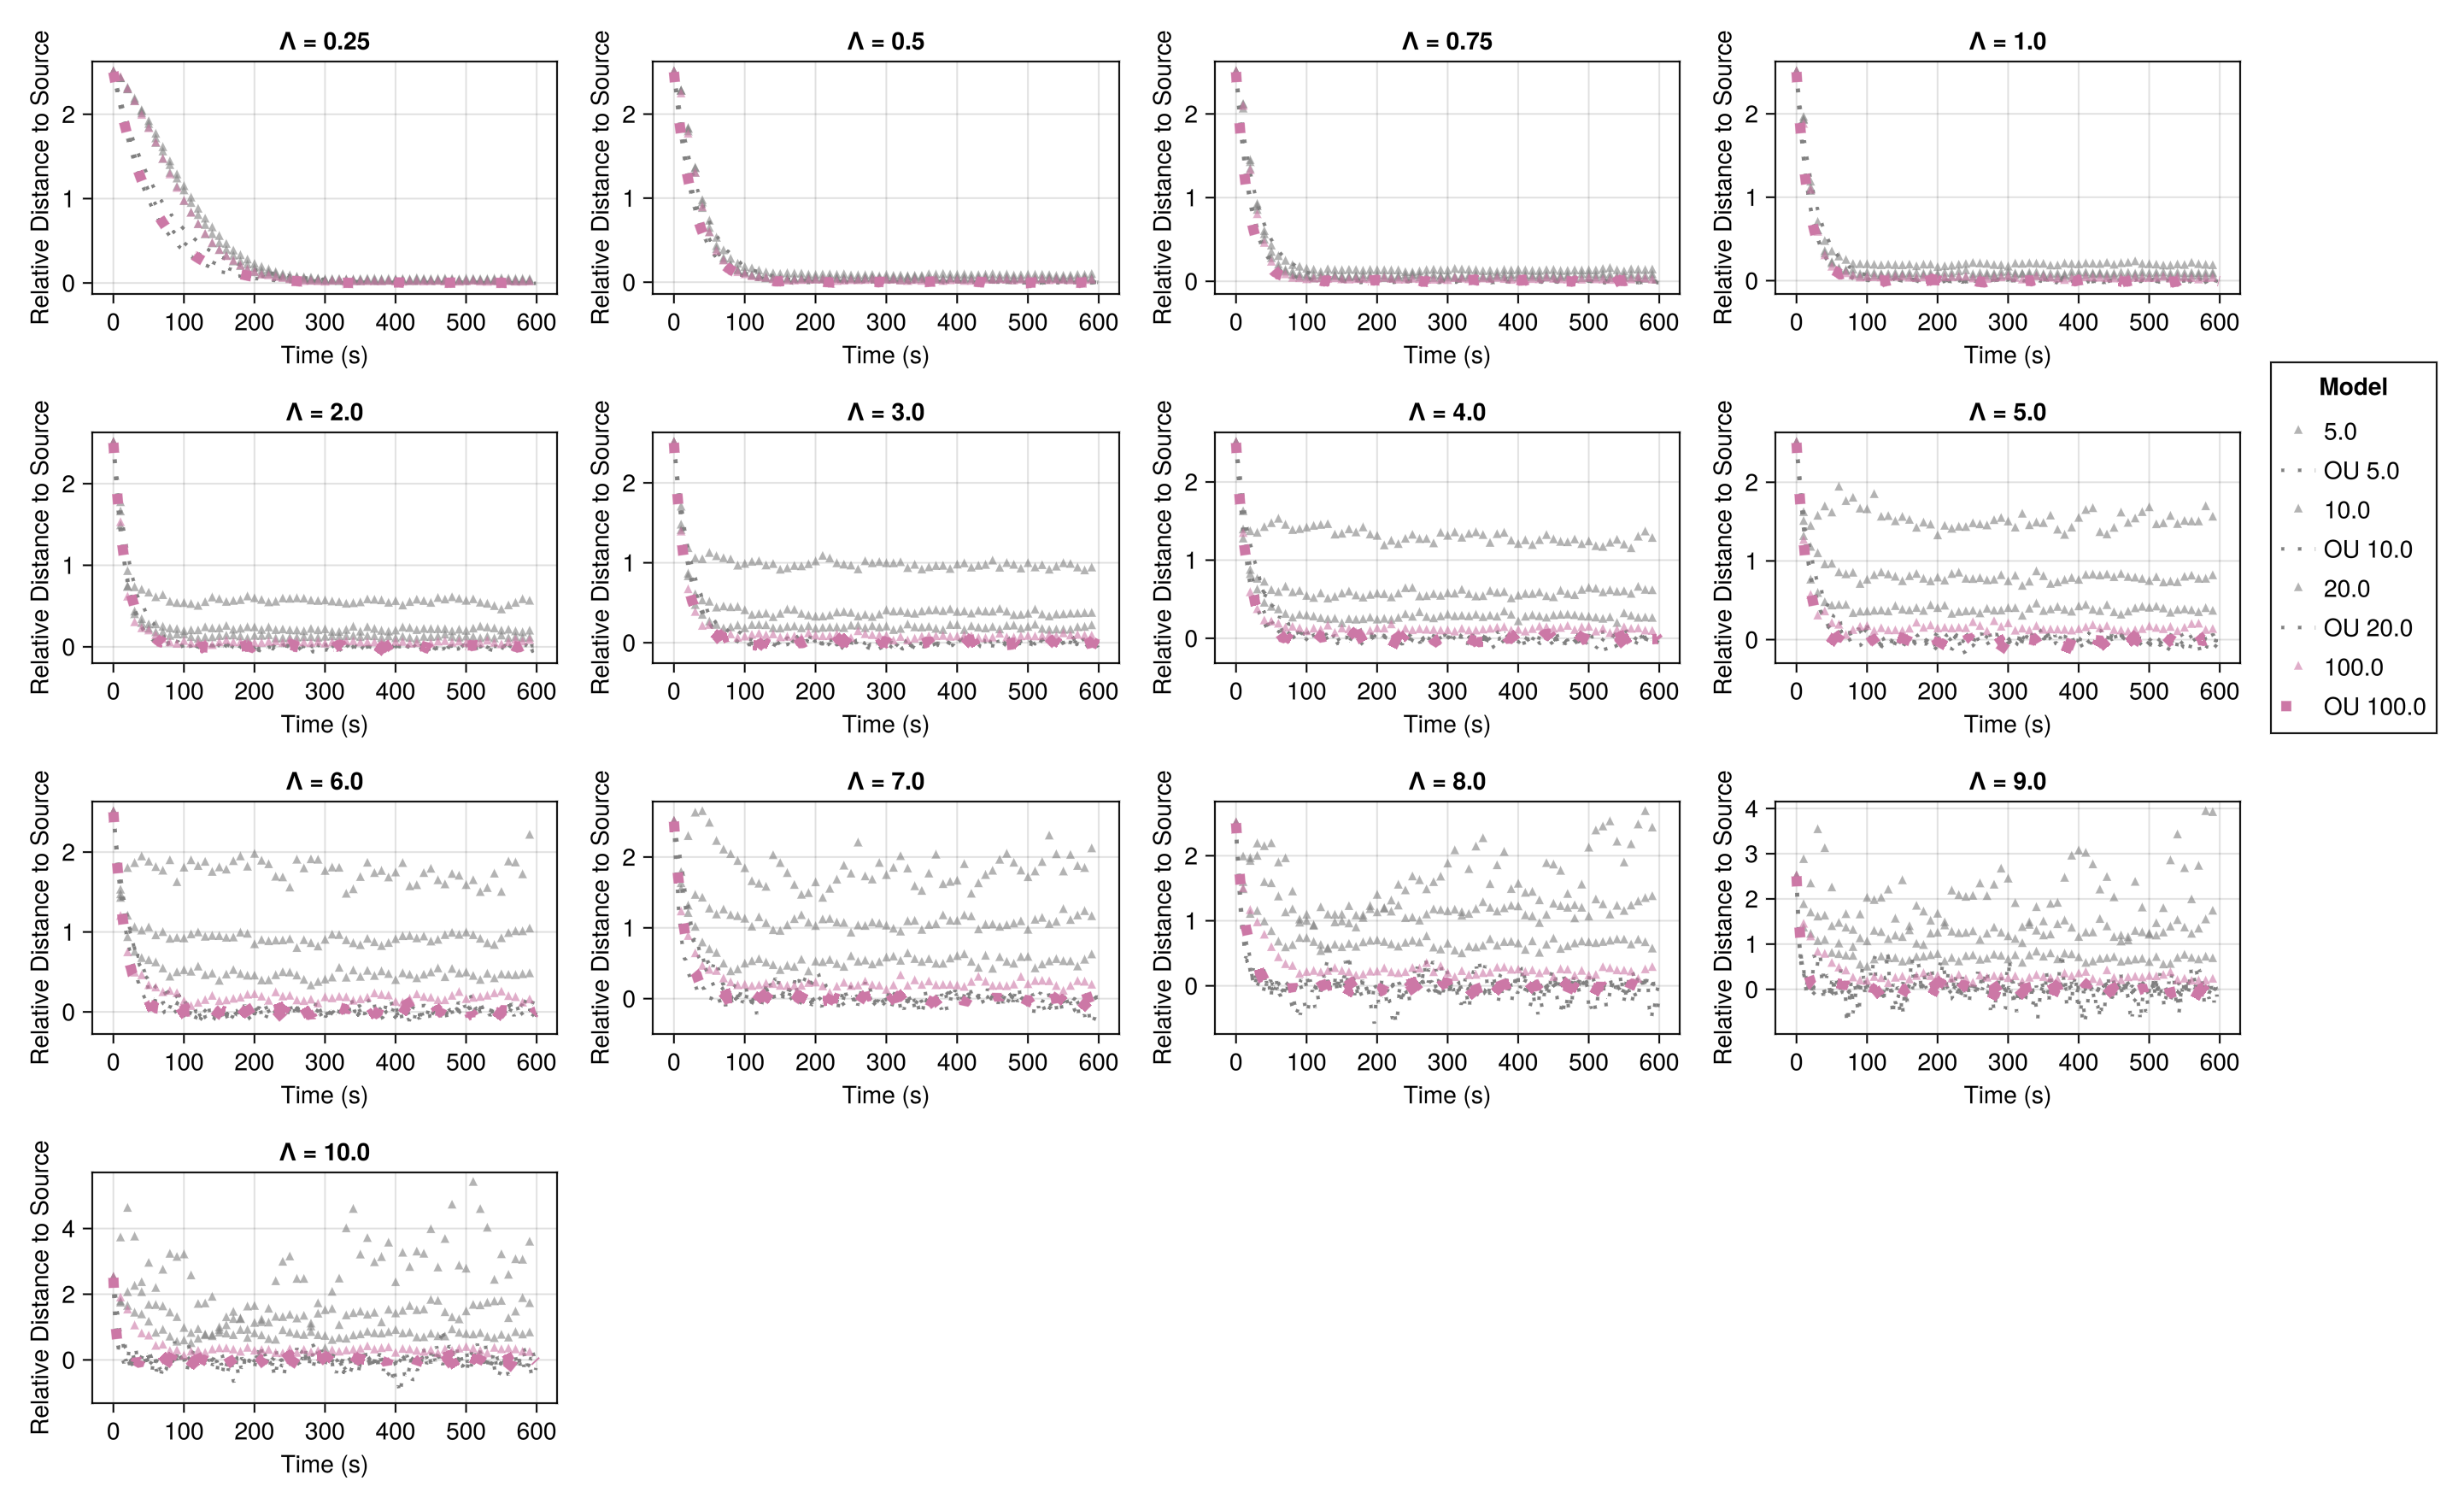

GLMakie.Screen(...)

In [10]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

# colors = distinguishable_colors(4, [RGB(1,1, 1), RGB(0, 0, 0)], dropseed = true, lchoices=range(70, stop=95, length = 15), cchoices=range(10, stop=40, length=15))
# colors = distinguishable_colors(
#     4,
#     [RGB(1,1,1), RGB(0,0,0)],
#     dropseed = true,
#     lchoices = range(50, stop=85, length=20),
#     cchoices = range(30, stop=80, length=20)
# )
# id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [
    :grey,   # blue
    :grey,   # orange
    :grey,  # green
    RGBf(0.80, 0.47, 0.65) # magenta
]
# colors = [:red, :blue, :green, :yellow]
# colors_2 = [:pink, :black, :brown, :orange]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))

widths = [2, 2, 2, 6]


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = combined_dfs[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        eq = grouped[3000:end]
        df_subset = DataFrame(eq)

        if lambda < 6.0

            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        else
            t = (thresholds[v_idx])/2
            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        end

        bad_agents = unique(df_subset[bad_rows_mask, :agent])

        df_clean = filter(row -> !(row.agent in bad_agents), df)

        if isempty(df_clean)
            @warn "No data for v=$v, lambda=$lambda. Skipping."
            continue
        end

        grouped_t = groupby(df_clean, :step)
        
        if isempty(grouped_t)
             @warn "No steps found in filtered data."
             continue
        end


        for i in 1:100:length(grouped_t)
            data_1 = grouped_t[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj.lambda .== lambda) .& (mean_traj.v .== v) 

        mean_OU = mean_traj.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        scatter!(ax_x, (1:100:length(grouped_t))*0.1, mean_x, color = color, label = "$v", alpha = 0.6, marker = :utriangle, markersize = 7, strokecolor = :black)
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = widths[v_idx], label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [11]:
save("Plots/Fixed_source_model/OU/OU_all_v100.png", fig2)

In [11]:
@load "redo_dfs.jld2" dfs_redo

1-element Vector{Symbol}:
 :dfs_redo

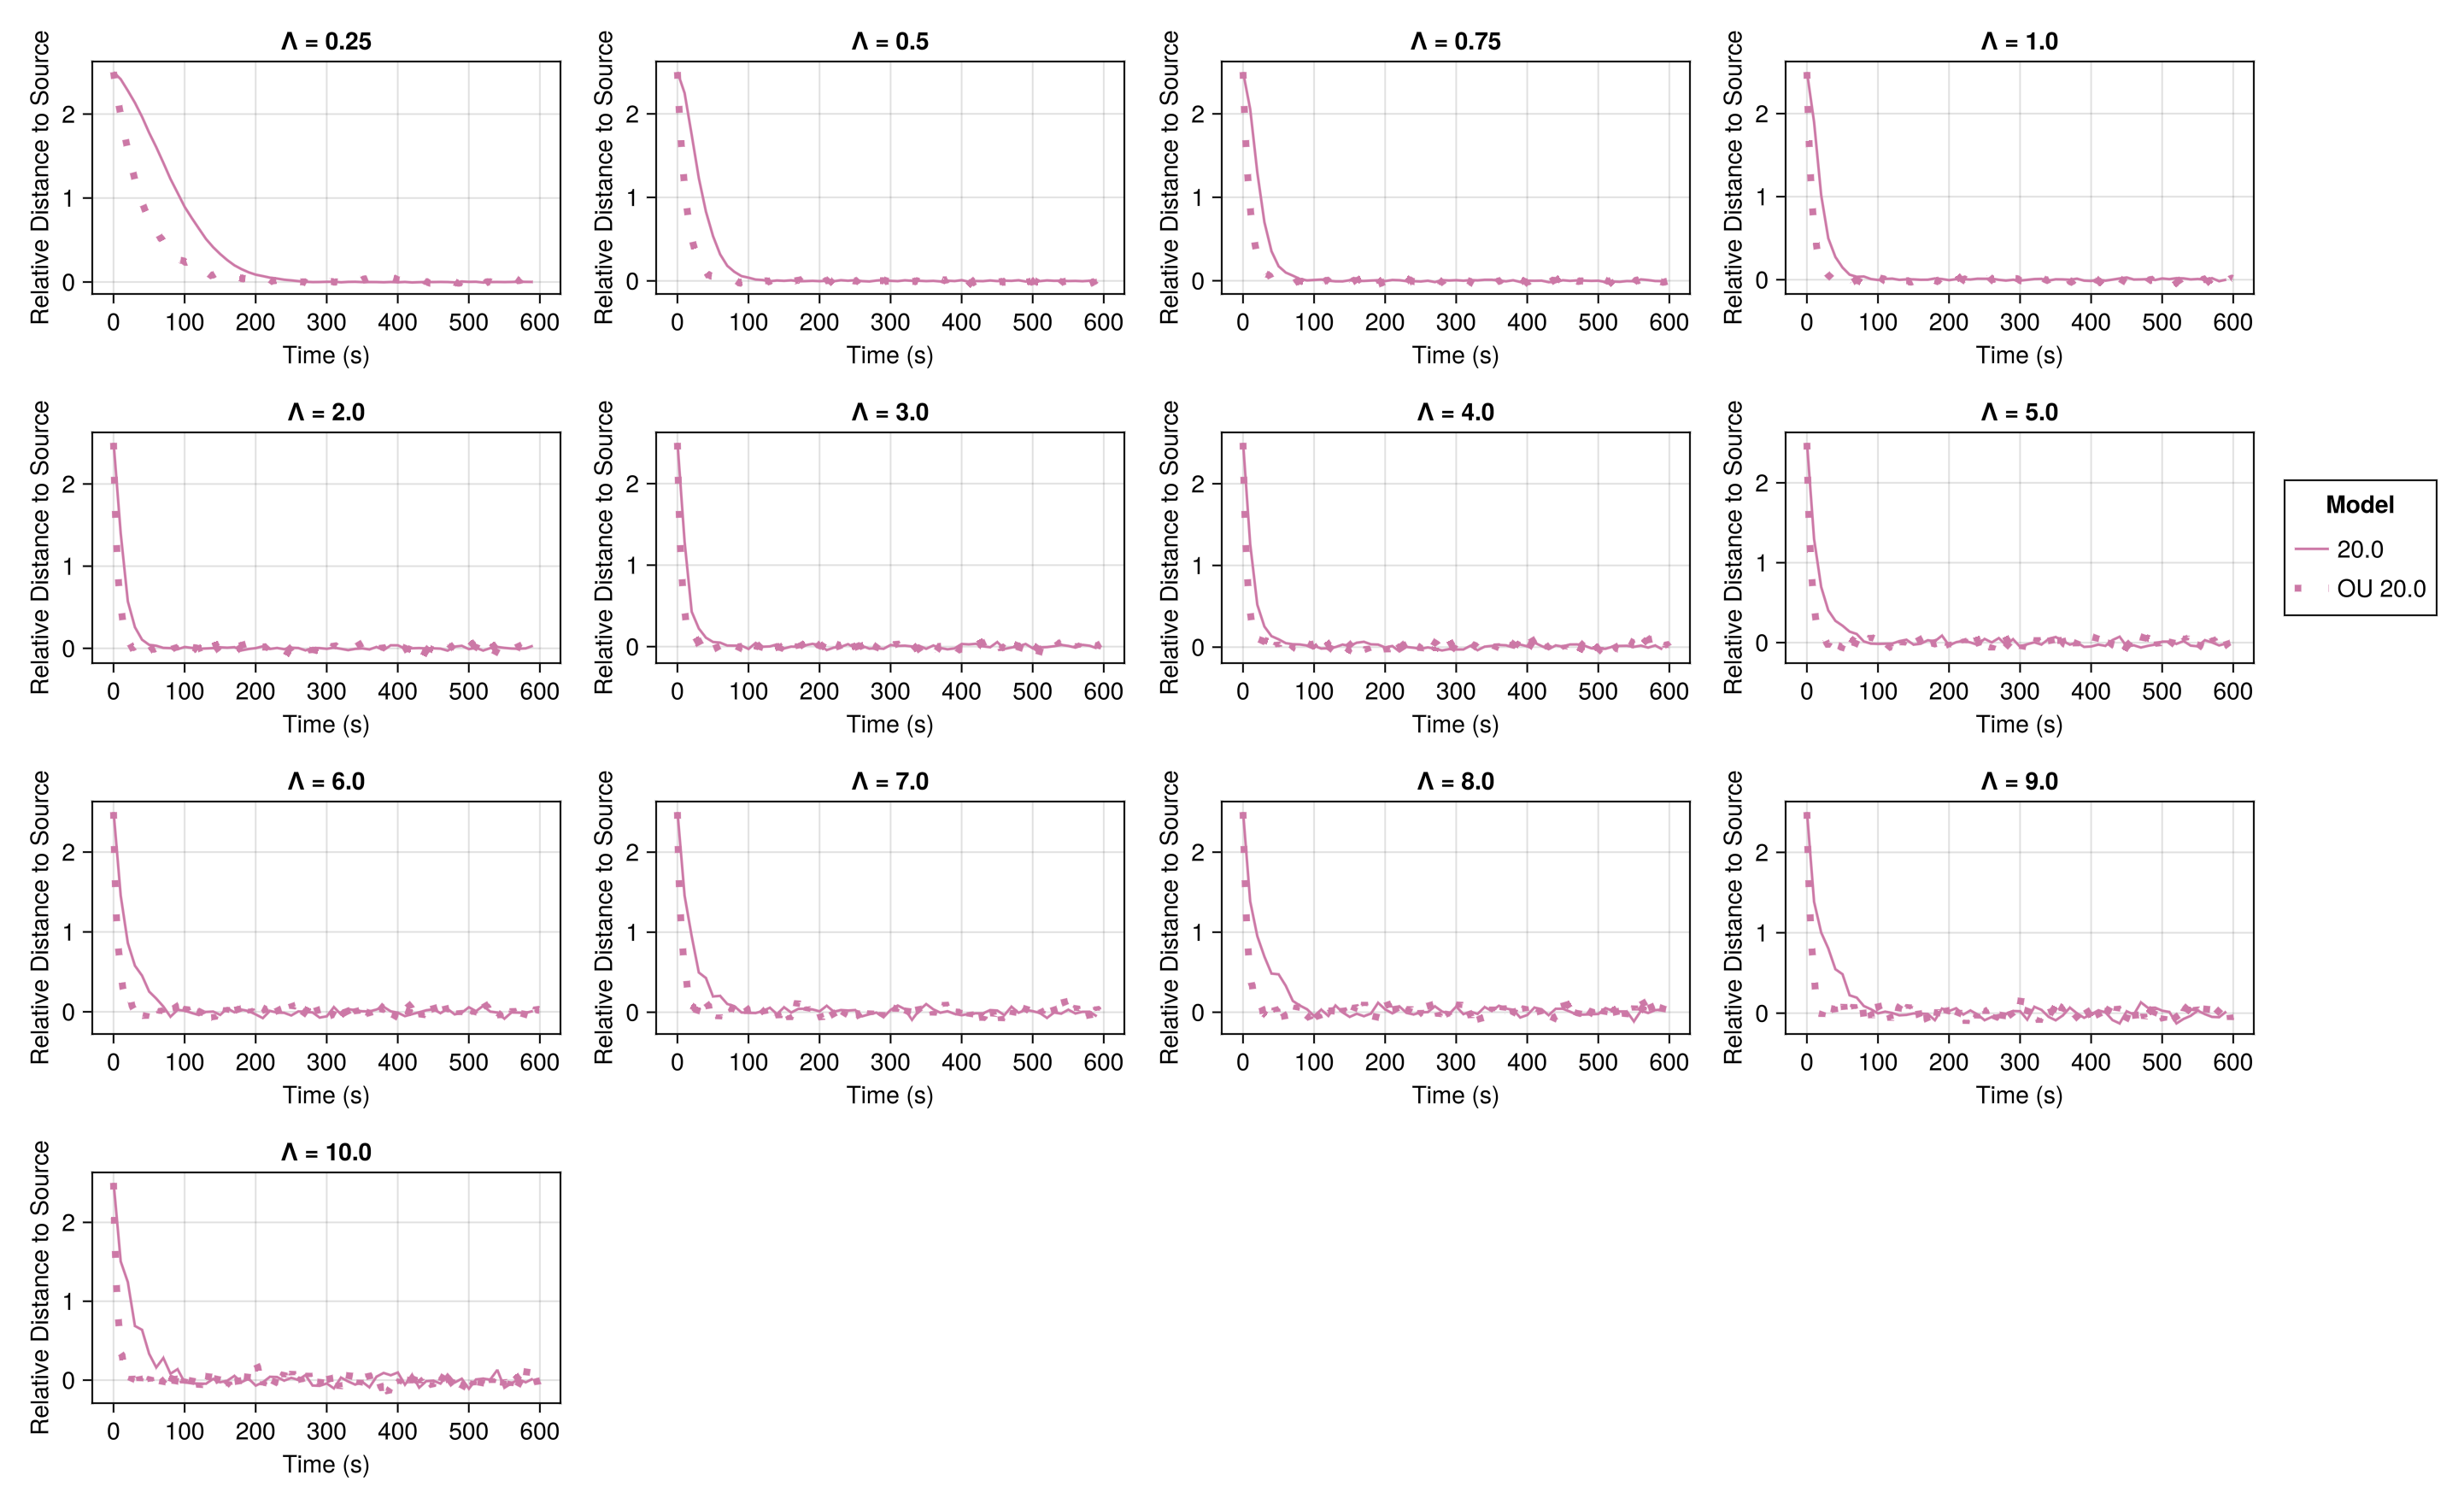

GLMakie.Screen(...)

In [20]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000


# velocities = [5.0]
# velocities = [10.0]
velocities = [20.0]
# velocities = [100.0]

# id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [
    RGBf(0.80, 0.47, 0.65)
]


# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))

for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) 

        mean_OU = mean_traj_redo.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 4, label = "OU $v")


        if idx == 13 & v_idx == 1
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [21]:
save("Plots/Fixed_source_model/Next/OU_v20_new.png", fig2)

In [42]:
@save "mean_traj_OU.jld2" mean_traj

In [5]:
@load "mean_traj_OU.jld2" mean_traj

1-element Vector{Symbol}:
 :mean_traj

In [ ]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
# thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

colors = [
    RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    RGBf(0.0, 0.62, 0.45),   # green
    RGBf(0.80, 0.47, 0.65)   # magenta
]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) 

        mean_OU = mean_traj_redo.mean[mask]
        mean_OU_norm = mean_OU ./ l 
        flat_vec = vcat(mean_OU_norm...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)